# 05. 딥러닝 기반 결함 분류 — ResNet-18 전이 학습

Severstal Steel Defect Detection 데이터 기반
- ResNet-18 Fine-tune: 전체 레이어 미세 조정
- ResNet-18 Feature Extractor: 백본 고정, 분류기만 학습
- Phase 1 ML(73.00%) vs Phase 2 DL 성능 비교
- Grad-CAM으로 모델 주목 영역 시각화

In [1]:
import os, sys, cv2, numpy as np, matplotlib.pyplot as plt, torch, time, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

from deep_learning.train_dl_severstal import get_device
device = get_device()
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.10.0


## Part 1: 데이터 준비

[Binary DataLoaders]
  Train: 1280 (정상 640 / 비정상 640)
  Test:  320 (정상 160 / 비정상 160)


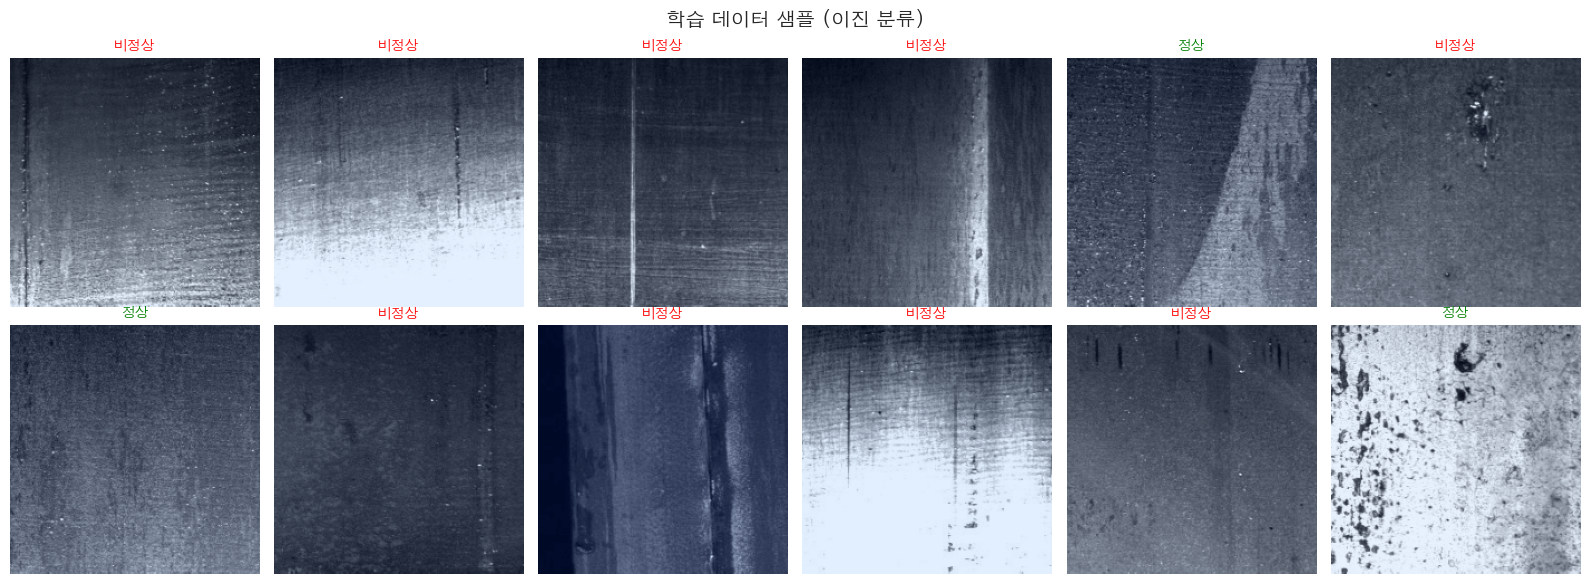

In [2]:
from deep_learning.datasets_severstal import get_binary_dataloaders

PATCH_DIR = os.path.join(PROJECT_ROOT, 'data', 'severstal_patches')
SAVE_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models_severstal', 'binary_dl')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures', 'severstal')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_loader, test_loader, class_names = get_binary_dataloaders(
    PATCH_DIR, max_per_class=800, batch_size=32, target_size=224, to_rgb=True
)

# 샘플 시각화
batch_imgs, batch_labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i in range(12):
    r, c = i // 6, i % 6
    img = batch_imgs[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[r, c].imshow(img)
    lbl = '정상' if batch_labels[i] == 0 else '비정상'
    axes[r, c].set_title(lbl, fontsize=10, color='green' if batch_labels[i]==0 else 'red')
    axes[r, c].axis('off')
fig.suptitle('학습 데이터 샘플 (이진 분류)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 2: ResNet-18 Fine-tune 학습

In [3]:
from deep_learning.models.resnet_transfer import get_resnet18_finetune
from deep_learning.train_dl_severstal import train_model

model_ft = get_resnet18_finetune(num_classes=2)
print(f"ResNet-18 Fine-tune 파라미터: {sum(p.numel() for p in model_ft.parameters()):,}")

result_ft = train_model(
    model_ft, train_loader, test_loader,
    num_epochs=10, lr=0.0001, patience=5,
    save_path=os.path.join(SAVE_DIR, 'binary_resnet18_finetune.pt'),
    model_name='ResNet-18 Fine-tune (Binary)', device=device,
)

[ResNet-18 Fine-tune] 총 파라미터: 11,177,538
[ResNet-18 Fine-tune] 학습 가능 파라미터: 11,177,538
ResNet-18 Fine-tune 파라미터: 11,177,538

[ResNet-18 Fine-tune (Binary)] 학습 시작 — device: mps
  Epochs: 10, LR: 0.0001, Patience: 5


  Epoch   1/10 | Train Loss: 0.4297 Acc: 0.7930 | Val Loss: 0.2825 Acc: 0.9031


  Epoch   2/10 | Train Loss: 0.1479 Acc: 0.9555 | Val Loss: 0.2468 Acc: 0.9031


  Epoch   3/10 | Train Loss: 0.0496 Acc: 0.9891 | Val Loss: 0.2961 Acc: 0.8875


  Epoch   4/10 | Train Loss: 0.0261 Acc: 0.9945 | Val Loss: 0.3382 Acc: 0.8875


...

  Epoch   7/10 | Train Loss: 0.0058 Acc: 1.0000 | Val Loss: 0.2580 Acc: 0.9219


  Epoch   8/10 | Train Loss: 0.0054 Acc: 1.0000 | Val Loss: 0.2682 Acc: 0.9219


  Epoch   9/10 | Train Loss: 0.0038 Acc: 1.0000 | Val Loss: 0.2683 Acc: 0.9219


  Epoch  10/10 | Train Loss: 0.0058 Acc: 0.9992 | Val Loss: 0.2692 Acc: 0.9187



  최종 결과: Accuracy=0.9219, 학습시간=59.3s


## Part 3: ResNet-18 Feature Extractor 학습

In [4]:
from deep_learning.models.resnet_transfer import get_resnet18_feature_extractor

model_fe = get_resnet18_feature_extractor(num_classes=2)
trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"ResNet-18 Feature Extractor 학습 가능 파라미터: {trainable:,}")

result_fe = train_model(
    model_fe, train_loader, test_loader,
    num_epochs=10, lr=0.001, patience=5,
    save_path=os.path.join(SAVE_DIR, 'binary_resnet18_feature_extractor.pt'),
    model_name='ResNet-18 Feature Extractor (Binary)', device=device,
)

[ResNet-18 Feature Extractor] 총 파라미터: 11,177,538
[ResNet-18 Feature Extractor] 학습 가능 파라미터: 8,394,754
ResNet-18 Feature Extractor 학습 가능 파라미터: 8,394,754

[ResNet-18 Feature Extractor (Binary)] 학습 시작 — device: mps
  Epochs: 10, LR: 0.001, Patience: 5


  Epoch   1/10 | Train Loss: 0.5601 Acc: 0.7750 | Val Loss: 0.4127 Acc: 0.8594


  Epoch   2/10 | Train Loss: 0.2599 Acc: 0.8953 | Val Loss: 0.4923 Acc: 0.8219


  Epoch   3/10 | Train Loss: 0.1312 Acc: 0.9469 | Val Loss: 0.4566 Acc: 0.8594


  Epoch   4/10 | Train Loss: 0.0826 Acc: 0.9695 | Val Loss: 0.3920 Acc: 0.8562


...

  Epoch   7/10 | Train Loss: 0.0246 Acc: 0.9922 | Val Loss: 0.4005 Acc: 0.8938


  Epoch   8/10 | Train Loss: 0.0073 Acc: 1.0000 | Val Loss: 0.4060 Acc: 0.9062


  Epoch   9/10 | Train Loss: 0.0070 Acc: 0.9984 | Val Loss: 0.4013 Acc: 0.9062


  Epoch  10/10 | Train Loss: 0.0045 Acc: 1.0000 | Val Loss: 0.3984 Acc: 0.9062



  최종 결과: Accuracy=0.9062, 학습시간=32.0s


## Part 4: 학습 곡선 비교

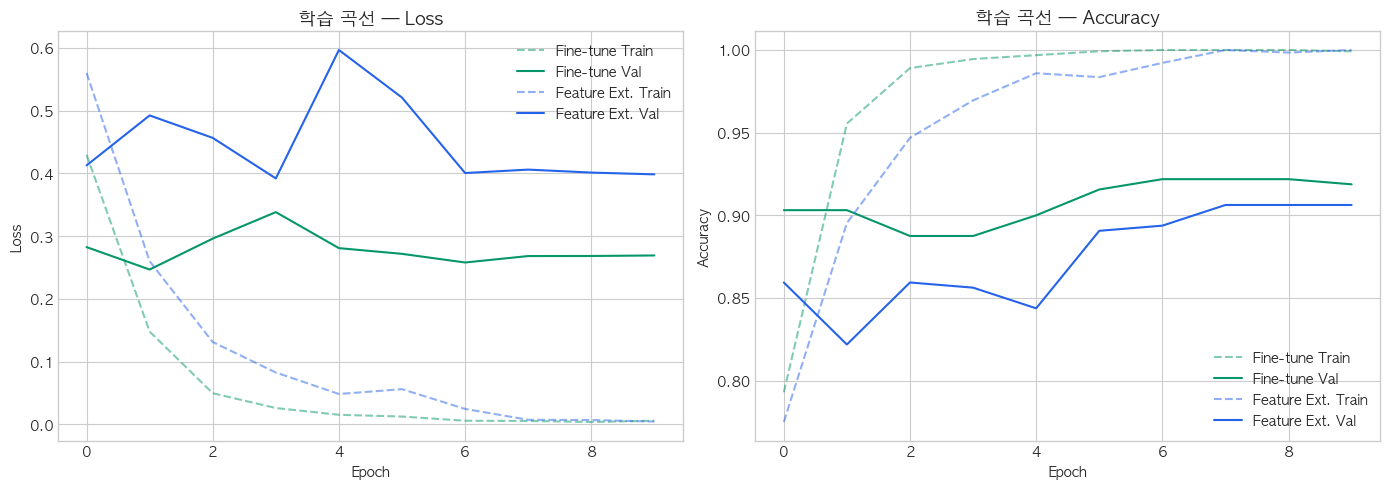

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for result, label, color in [
    (result_ft, 'Fine-tune', '#059669'),
    (result_fe, 'Feature Ext.', '#2563eb'),
]:
    h = result['history']
    axes[0].plot(h['train_loss'], '--', color=color, alpha=0.5, label=f'{label} Train')
    axes[0].plot(h['val_loss'], '-', color=color, label=f'{label} Val')
    axes[1].plot(h['train_acc'], '--', color=color, alpha=0.5, label=f'{label} Train')
    axes[1].plot(h['val_acc'], '-', color=color, label=f'{label} Val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('학습 곡선 — Loss', fontsize=13, fontweight='bold')
axes[0].legend()

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('학습 곡선 — Accuracy', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_dl_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 5: Phase 1 ML vs Phase 2 DL 성능 비교

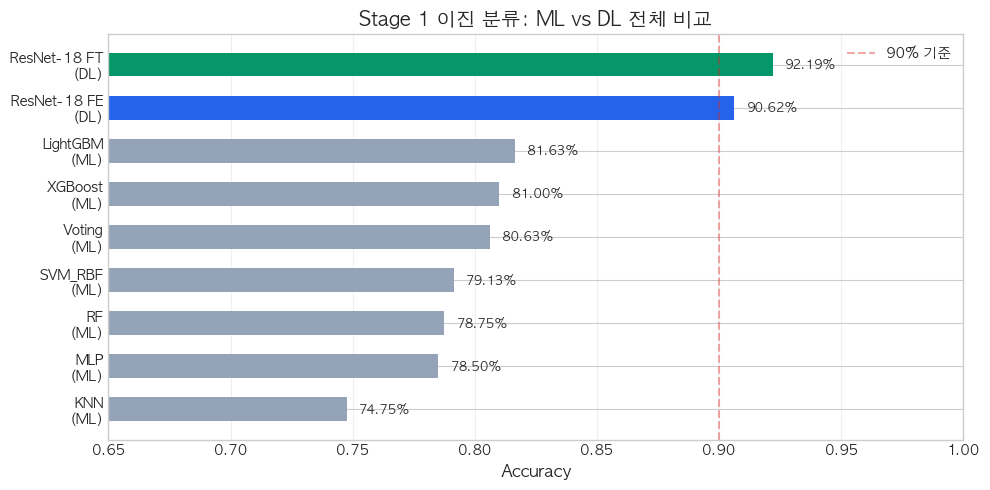


ML 최고 (LightGBM): 81.63%
DL Fine-tune: 92.19%
DL Feature Ext.: 90.62%
→ DL vs ML 향상: +10.56%p


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

models = ['KNN\n(ML)', 'MLP\n(ML)', 'RF\n(ML)', 'SVM_RBF\n(ML)', 'Voting\n(ML)',
          'XGBoost\n(ML)', 'LightGBM\n(ML)', 'ResNet-18 FE\n(DL)', 'ResNet-18 FT\n(DL)']
accs = [0.7475, 0.7850, 0.7875, 0.7913, 0.8063, 0.8100, 0.8163,
        result_fe['best_accuracy'], result_ft['best_accuracy']]
colors = ['#94a3b8']*7 + ['#2563eb', '#059669']

bars = ax.barh(models, accs, color=colors, height=0.55)
ax.set_xlim(0.65, 1.0)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Stage 1 이진 분류: ML vs DL 전체 비교', fontsize=14, fontweight='bold')
ax.axvline(x=0.9, color='#dc2626', linestyle='--', alpha=0.4, label='90% 기준')
ax.grid(True, alpha=0.3, axis='x')
ax.legend()
for i, v in enumerate(accs):
    ax.text(v + 0.005, i, f'{v:.2%}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_ml_vs_dl_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nML 최고 (LightGBM): 81.63%")
print(f"DL Fine-tune: {result_ft['best_accuracy']:.2%}")
print(f"DL Feature Ext.: {result_fe['best_accuracy']:.2%}")
print(f"→ DL vs ML 향상: +{(result_ft['best_accuracy'] - 0.8163)*100:.2f}%p")

## Part 6: 혼동행렬 (Best 모델)

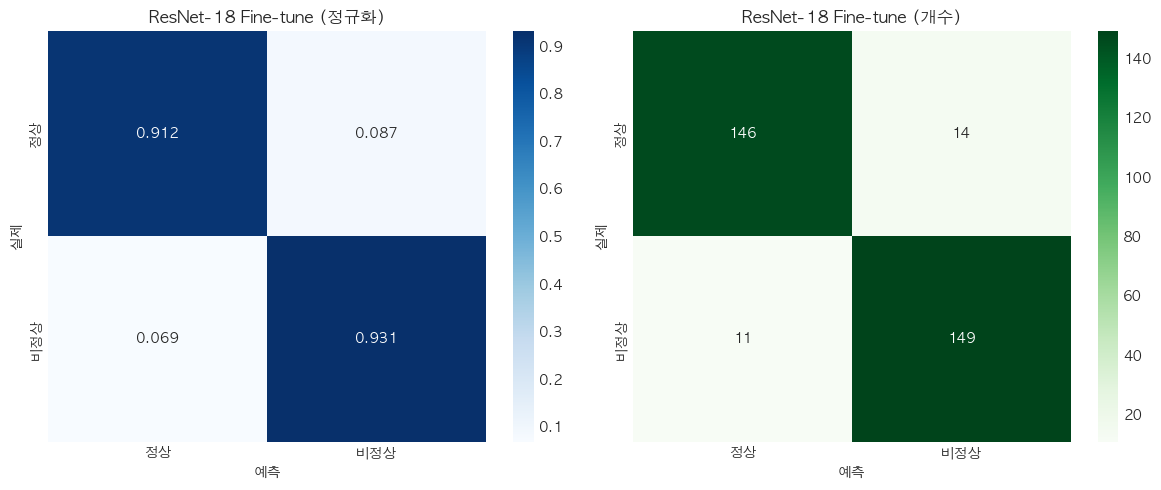

              precision    recall  f1-score   support

          정상       0.93      0.91      0.92       160
         비정상       0.91      0.93      0.92       160

    accuracy                           0.92       320
   macro avg       0.92      0.92      0.92       320
weighted avg       0.92      0.92      0.92       320



In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best = result_ft if result_ft['best_accuracy'] >= result_fe['best_accuracy'] else result_fe
best_name = 'ResNet-18 Fine-tune' if result_ft['best_accuracy'] >= result_fe['best_accuracy'] else 'ResNet-18 Feature Ext.'

cm = confusion_matrix(best['y_true'], best['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '비정상'], yticklabels=['정상', '비정상'])
axes[0].set_title(f'{best_name} (정규화)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('예측'); axes[0].set_ylabel('실제')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['정상', '비정상'], yticklabels=['정상', '비정상'])
axes[1].set_title(f'{best_name} (개수)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('예측'); axes[1].set_ylabel('실제')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_dl_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(best['y_true'], best['y_pred'], target_names=['정상', '비정상']))

## 결론

### 핵심 발견
1. **ResNet-18 Fine-tune**: 92.19% → ML 최고(73.00%) 대비 **+19.19%p 향상**
2. **Feature Extractor**: 90.62% → Fine-tune과 유사, 학습 파라미터 적어 빠름
3. **전이 학습의 위력**: ImageNet 사전 학습이 철강 결함 도메인에서도 효과적
4. **특징 자동 학습**: 수동 HOG/LBP 특징 설계 없이 CNN이 자동으로 최적 특징 학습

→ 다음 노트북(06)에서 이상 탐지(Autoencoder)로 비지도 학습 접근을 시도합니다.